In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

from tp7.tp7 import Tape7
from srfs.srfs import SRFS
import scipy.integrate as integrate
from collections import defaultdict
import seaborn as sns

In [2]:
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

a00_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("../data/Modtran_Unfiltering_Tape7s_SZA85")

# Building Dataset v1
1 tape7 file -> load tape7 file -> build scene df -> compute filtered radiances -> combine into one df

In [3]:
a00_files

['./data/Modtran_Unfiltering_Tape7s_SZA00/sno_sz00L.tp7',
 './data/Modtran_Unfiltering_Tape7s_SZA00/lnd_sz00L.tp7',
 './data/Modtran_Unfiltering_Tape7s_SZA00/oceclr_sz00L.tp7',
 './data/Modtran_Unfiltering_Tape7s_SZA00/ocecld_sz00L.tp7',
 './data/Modtran_Unfiltering_Tape7s_SZA00/dc_sz00.spectra.tp7']

In [4]:
# a00_data = [Tape7(file) for file in a00_files]
# titles = [file.title for file in a00_data]
# a00 = {title: file for title, file in zip(titles, a00_data)}
tp7_objs = [Tape7(a00_files[1]), Tape7(a41_files[2])]
titles = [file.title for file in tp7_objs]
lnd_ocnclr = {title: file for title, file in zip(titles, tp7_objs)}
lnd_ocnclr

{'Land': <tp7.tp7.Tape7 at 0x16b4a7aa0>,
 'Clear Ocean': <tp7.tp7.Tape7 at 0x1681deff0>}

In [5]:
land = lnd_ocnclr['Land']
ocnclr = lnd_ocnclr['Clear Ocean']


land._compute_radiences()
ocnclr._compute_radiences()

array([[[2.5000000e-01, 2.5006000e-01, 2.5013000e-01, ...,
         3.3333331e+02, 4.9999994e+02, 9.9999988e+02],
        [9.8272000e-12, 9.2649000e-12, 9.4496000e-12, ...,
         4.1136000e-24, 4.5194000e-25, 9.6935228e-27],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         1.6570000e-07, 7.8788000e-08, 2.1349000e-08]],

       [[2.5000000e-01, 2.5006000e-01, 2.5013000e-01, ...,
         3.3333331e+02, 4.9999994e+02, 9.9999988e+02],
        [9.8348000e-12, 9.2720000e-12, 9.4568000e-12, ...,
         4.1135000e-24, 4.5194000e-25, 9.6935228e-27],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         1.6570000e-07, 7.8788000e-08, 2.1349000e-08]],

       [[2.5000000e-01, 2.5006000e-01, 2.5013000e-01, ...,
         3.3333331e+02, 4.9999994e+02, 9.9999988e+02],
        [9.8348000e-12, 9.2720000e-12, 9.4568000e-12, ...,
         4.1135000e-24, 4.5194000e-25, 9.6935228e-27],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         1.6570000e-07, 7

In [6]:
srf = SRFS("../data/libera_srfs_20241017.csv")

In [7]:
srf.srf_vals

,wavelength [um],ssw srf,conv ssw srf,lw srf,conv lw srf,total srf,conv total srf,sw srf,conv sw srf,End_wv_range
0,0.000000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.300000
0,0.300000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.301750
1,0.301750,0.0,0.0,0.00000,0.00000,0.00965,0.00965,0.01006,0.01006,0.303509
2,0.303509,0.0,0.0,0.00000,0.00000,0.01077,0.01076,0.00933,0.00933,0.305279
3,0.305279,0.0,0.0,0.00000,0.00000,0.01182,0.01178,0.00863,0.00865,0.307060
...,...,...,...,...,...,...,...,...,...,...
995,97.700859,0.0,0.0,0.44098,0.45646,0.89716,0.89719,-0.00000,-0.00000,98.270641
996,98.270641,0.0,0.0,0.50463,0.49343,0.89582,0.89590,-0.00000,-0.00000,98.843745
997,98.843745,0.0,0.0,0.56496,0.52561,0.89447,0.89473,-0.00000,-0.00000,99.420192
998,99.420192,0.0,0.0,0.57120,0.54465,0.89312,0.89376,-0.00000,-0.00000,100.000000


In [8]:
tot_wvln = srf.srf_vals['wavelength [um]']
sw_srf = srf.srf_vals[' sw srf']
lw_srf = srf.srf_vals[' lw srf']

In [9]:
all_integrated_radiances_land = land.integrate_radiances(tot_wvln, sw_srf, lw_srf)

In [10]:
sw_unfilt_lnd, sw_filt_land = all_integrated_radiances_land[0], all_integrated_radiances_land[2]

In [11]:
def plot_radiance(rads, title, runnum, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(rads[runnum, 0, :], rads[runnum, s_or_l, :], 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 2:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)

In [12]:
def plot_integrated_radiance(rads):
    plt.figure(figsize=(8, 4))  # Optional: Adjusts the figure size
    plt.plot(rads, marker='o', linestyle='-', label='Array Values')  # Line plot
    plt.title('1D Array Visualization')  # Add a title
    plt.xlabel('Index')  # Label for x-axis
    plt.ylabel('Value')  # Label for y-axis
    plt.grid(True)  # Add a grid
    plt.legend()  # Add a legend
    plt.show()

In [13]:
r1, r100, r250, r450, r630 = land.rads[0, 0, :], land.rads[99, 0, :], land.rads[249, 0, :], land.rads[449, 0, :], land.rads[629, 0, :]

In [14]:
set(r1) == set(r100), set(r1) == set(r250), set(r1) == set(r450), set(r1) == set(r630)

(True, True, True, True)

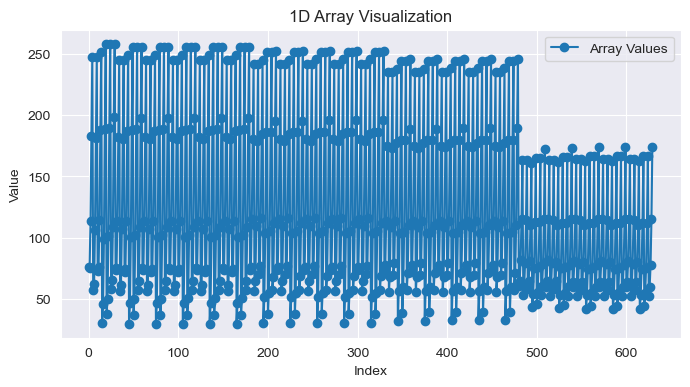

In [15]:
plot_integrated_radiance(sw_filt_land)

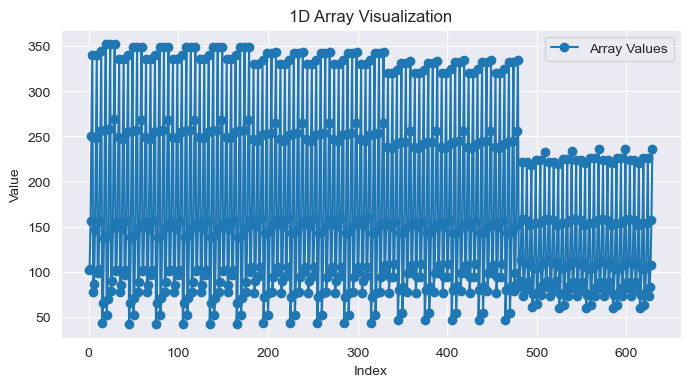

In [16]:
plot_integrated_radiance(sw_unfilt_lnd)

In [17]:
land.describer_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Land,0.0,0.000,0.0,0,0,101.967819,98.435473,75.727145,0.016809
1,Land,0.0,0.000,0.0,1,1,103.227094,69.392565,75.293403,0.003139
2,Land,0.0,0.000,0.0,1,2,155.619541,60.644086,113.325768,0.002398
3,Land,0.0,0.000,0.0,1,3,250.712675,93.578042,183.088022,0.021329
4,Land,0.0,0.000,0.0,1,4,339.815605,86.650577,247.891967,0.029803
...,...,...,...,...,...,...,...,...,...,...
625,Land,0.0,79.914,172.5,0,625,72.466530,58.907500,52.043946,0.001230
626,Land,0.0,79.914,172.5,1,626,83.026982,46.597913,59.707949,0.002290
627,Land,0.0,79.914,172.5,1,627,106.881209,44.111608,77.204551,0.002583
628,Land,0.0,79.914,172.5,1,628,157.489675,58.372397,114.987698,0.008196


In [18]:
all_integrated_radiances_ocnclr = ocnclr.integrate_radiances(tot_wvln, sw_srf, lw_srf)

In [19]:
ocnclr.describer_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Clear Ocean,41.387,0.000,0.0,0,0,3.136356e-08,0.000566,2.119963e-08,3.972862e-11
1,Clear Ocean,41.387,0.000,0.0,0,1,3.712243e-08,0.000562,2.557288e-08,4.904813e-11
2,Clear Ocean,41.387,0.000,0.0,0,2,4.095820e-08,0.000558,2.851947e-08,5.892940e-11
3,Clear Ocean,41.387,0.000,0.0,0,3,4.840163e-08,0.000556,3.424651e-08,7.892688e-11
4,Clear Ocean,41.387,0.000,0.0,0,4,6.282374e-08,0.000554,4.535346e-08,1.188249e-10
...,...,...,...,...,...,...,...,...,...,...
142,Clear Ocean,40.375,89.947,172.5,0,142,2.035709e-07,0.000476,1.520152e-07,5.431468e-11
143,Clear Ocean,40.375,89.947,172.5,0,143,2.200970e-07,0.000476,1.652269e-07,6.449368e-11
144,Clear Ocean,40.375,89.947,172.5,0,144,2.429102e-07,0.000476,1.833262e-07,8.296269e-11
145,Clear Ocean,40.375,89.947,172.5,0,145,2.838958e-07,0.000476,2.156186e-07,1.020558e-10


In [20]:
ocnclr_lnd_df = pd.concat([land.describer_df, ocnclr.describer_df], ignore_index=True)
ocnclr_lnd_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Land,0.000,0.000,0.0,0,0,1.019678e+02,98.435473,7.572715e+01,1.680891e-02
1,Land,0.000,0.000,0.0,1,1,1.032271e+02,69.392565,7.529340e+01,3.139096e-03
2,Land,0.000,0.000,0.0,1,2,1.556195e+02,60.644086,1.133258e+02,2.397553e-03
3,Land,0.000,0.000,0.0,1,3,2.507127e+02,93.578042,1.830880e+02,2.132931e-02
4,Land,0.000,0.000,0.0,1,4,3.398156e+02,86.650577,2.478920e+02,2.980253e-02
...,...,...,...,...,...,...,...,...,...,...
772,Clear Ocean,40.375,89.947,172.5,0,142,2.035709e-07,0.000476,1.520152e-07,5.431468e-11
773,Clear Ocean,40.375,89.947,172.5,0,143,2.200970e-07,0.000476,1.652269e-07,6.449368e-11
774,Clear Ocean,40.375,89.947,172.5,0,144,2.429102e-07,0.000476,1.833262e-07,8.296269e-11
775,Clear Ocean,40.375,89.947,172.5,0,145,2.838958e-07,0.000476,2.156186e-07,1.020558e-10


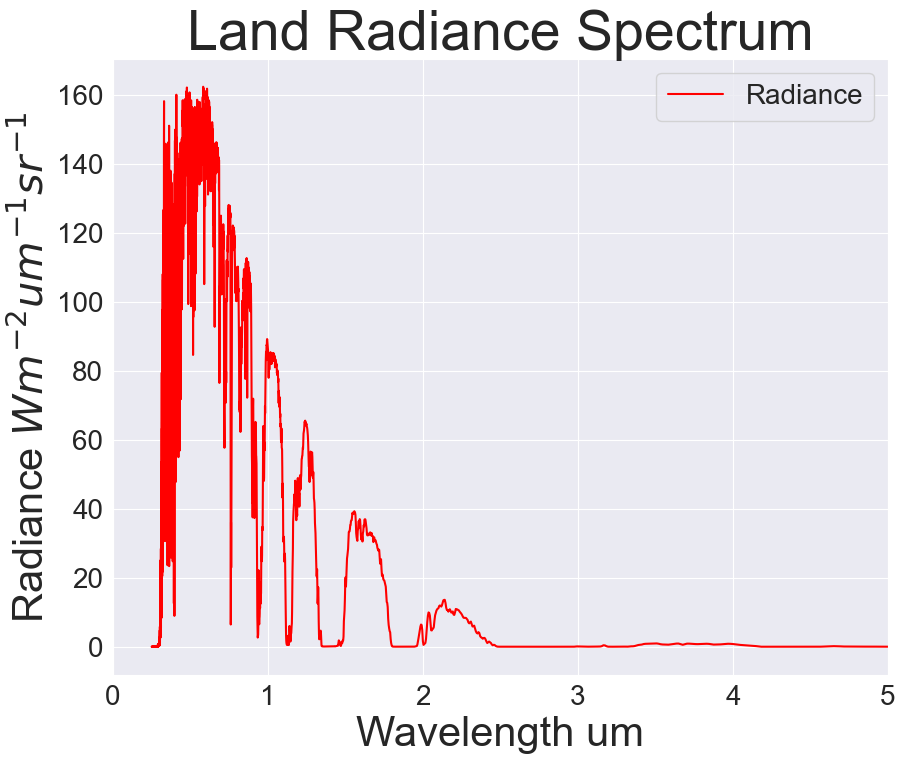

In [21]:
plot_radiance(land.rads, land.title, 0, 1)

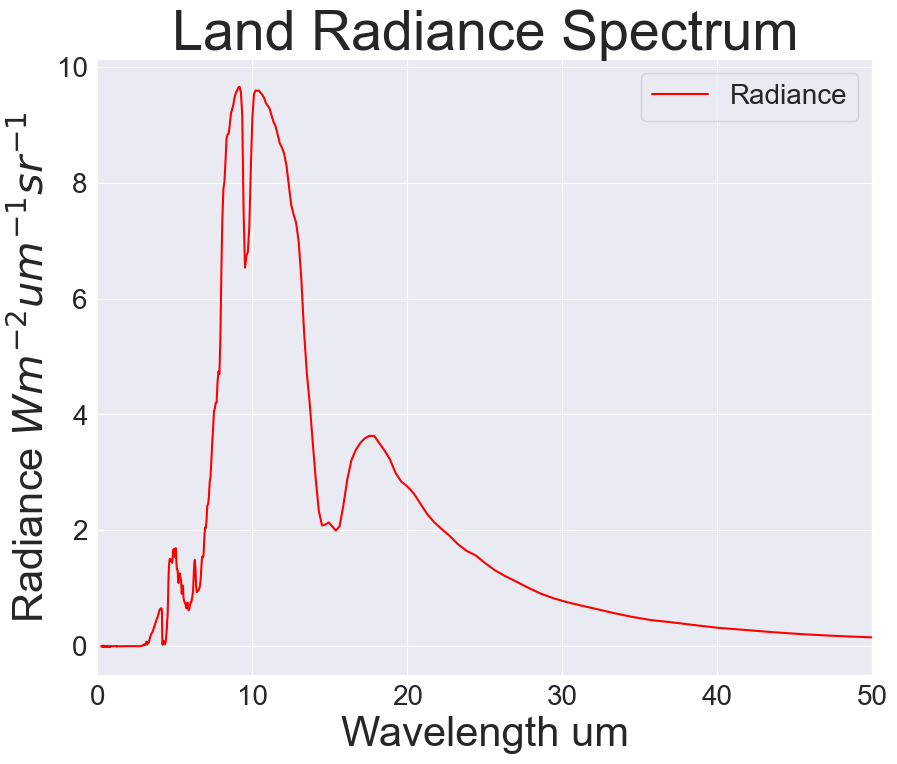

In [22]:
plot_radiance(land.rads, land.title, 0, 2)

In [23]:
land.rads.shape

(630, 3, 4000)

In [24]:
for i in land.rads[0, 0, :]:
    print(i)

0.25
0.2500625156289072
0.25012506253126565
0.25018764073054794
0.2502502502502503
0.2503128911138924
0.25037556334501754
0.2504382669671926
0.250501002004008
0.25056376847907796
0.2506265664160401
0.25068939583855604
0.25075225677031093
0.2508151492350138
0.2508780732563974
0.25094102885821834
0.25100401606425704
0.25106703489831783
0.25113008538422904
0.25119316754584275
0.25125628140703515
0.25131942699170645
0.2513826043237808
0.25144581342720645
0.2515090543259557
0.25157232704402516
0.25163563160543534
0.2516989680342311
0.25176233635448136
0.2518257365902795
0.2518891687657431
0.25195263290501385
0.25201612903225806
0.25207965717166625
0.2521432173474533
0.25220680958385877
0.2522704339051463
0.25233409033560433
0.2523977788995457
0.25246149962130776
0.25252525252525254
0.2525890376357666
0.25265285497726125
0.25271670457417234
0.2527805864509606
0.2528445006321113
0.25290844714213456
0.25297242600556535
0.25303643724696356
0.2531004808909137
0.25316455696202533
0.25322866548493

In [25]:
# plot_radiance(ocnclr.rads,ocnclr.title, 0)

In [26]:
# Define the input data
data = [
    ("M1", 0.415, 0.02),
    ("M2", 0.445, 0.02),
    ("M3", 0.49, 0.02),
    ("M4", 0.555, 0.02),
    ("I1", 0.64, 0.075),
    ("M5", 0.673, 0.021),
    ("DNB", 0.7, 0.4),
    ("M6", 0.746, 0.021),
    ("I2", 0.865, 0.039),
    ("M7", 0.865, 0.039),
    ("M8", 1.24, 0.02),
    ("M9", 1.378, 0.02),
    ("I3", 1.61, 0.06),
    ("M10", 1.61, 0.06),
    ("M11", 2.25, 0.05),
    ("I4", 3.74, 0.38),
    ("M12", 3.7, 0.18),
    ("M13", 4.05, 0.155),
    ("M14", 8.55, 0.3),
    ("M15", 10.763, 1),
    ("I5", 11.45, 1.9),
    ("M16", 12.013, .95),  # End width not provided
]

# Parse the data into the required array format
viirs_bands = {}
for nm, center, width in data:
    if width is not None:
        start = center - width
        end = center + width
        viirs_bands[nm] = (start, end)

# Display the result
viirs_bands

{'M1': (0.39499999999999996, 0.435),
 'M2': (0.425, 0.465),
 'M3': (0.47, 0.51),
 'M4': (0.535, 0.5750000000000001),
 'I1': (0.5650000000000001, 0.715),
 'M5': (0.652, 0.6940000000000001),
 'DNB': (0.29999999999999993, 1.1),
 'M6': (0.725, 0.767),
 'I2': (0.826, 0.904),
 'M7': (0.826, 0.904),
 'M8': (1.22, 1.26),
 'M9': (1.3579999999999999, 1.398),
 'I3': (1.55, 1.6700000000000002),
 'M10': (1.55, 1.6700000000000002),
 'M11': (2.2, 2.3),
 'I4': (3.3600000000000003, 4.12),
 'M12': (3.52, 3.8800000000000003),
 'M13': (3.895, 4.205),
 'M14': (8.25, 8.850000000000001),
 'M15': (9.763, 11.763),
 'I5': (9.549999999999999, 13.35),
 'M16': (11.063, 12.963)}

In [27]:
viirs_rads_indxs = defaultdict(list)
wv_00 = land.rads[0, 0, :]
vb_idx = 0
idx = 0
check = 0
for band, rng in viirs_bands.items():
    temp = []
    for idx in range(len(wv_00)):
        check += 1
        if rng[0] <= wv_00[idx] <= rng[1]:
            temp.append(idx)
    if temp:
        viirs_rads_indxs[band].append(temp[0])
        viirs_rads_indxs[band].append(temp[-1])

check % 4000

0

In [28]:
viirs_rads_indxs

defaultdict(list,
            {'M1': [1469, 1701],
             'M2': [1648, 1849],
             'M3': [1873, 2039],
             'M4': [2131, 2260],
             'I1': [2231, 2601],
             'M5': [2467, 2559],
             'DNB': [667, 3090],
             'M6': [2621, 2696],
             'I2': [2790, 2893],
             'M7': [2790, 2893],
             'M8': [3181, 3206],
             'M9': [3264, 3284],
             'I3': [3355, 3401],
             'M10': [3355, 3401],
             'M11': [3546, 3565],
             'I4': [3703, 3757],
             'M12': [3716, 3742],
             'M13': [3744, 3762],
             'M14': [3879, 3887],
             'M15': [3898, 3914],
             'I5': [3896, 3925],
             'M16': [3910, 3922]})

In [29]:
sw_00 = land.rads[0, 1, :]
lw_00 = land.rads[0, 2, :]

In [30]:
sw_bands_integrated = []
lw_bands_integrated = []
for band in viirs_rads_indxs:
    y_vals = sw_00[viirs_rads_indxs[band][0]: viirs_rads_indxs[band][1] + 1]
    x_vals = wv_00[viirs_rads_indxs[band][0]: viirs_rads_indxs[band][1] + 1]
    sw_int = -integrate.simpson(y=y_vals, x=x_vals)

    lw_y_vals = lw_00[viirs_rads_indxs[band][0]: viirs_rads_indxs[band][1] + 1]
    lw_int = -integrate.simpson(y=lw_y_vals, x=x_vals)
    print(band, sw_int, lw_int, (sw_int + lw_int))

M1 -4.4424153031346405 1.9600003828213308e-06 -4.442413343134258
M2 -4.988403002376088 -4.4328719484606655e-06 -4.988407435248036
M3 -5.780654001180237 2.666668039823123e-06 -5.780651334512197
M4 -5.849696627970182 1.9163779398519954e-06 -5.849694711592242
I1 -20.733589006148534 1.9666718653672642e-06 -20.733587039476667
M5 -5.553766863009578 -4.166671818655166e-06 -5.553771029681396
DNB -80.87452030121615 3.238380798842646e-05 -80.87448791740816
M6 -4.035412913238624 9.59930984015375e-06 -4.035403313928784
I2 -7.446944639527288 2.6164822461216293e-06 -7.446942023045042
M7 -7.446944639527288 2.6164822461216293e-06 -7.446942023045042
M8 -2.3964419903261156 -2.0595438829113105e-06 -2.3964440498699986
M9 -0.0025924668867464045 2.7111033762816214e-10 -0.0025924666156360667
I3 -4.0986889242718085 -8.038291290943433e-07 -4.098689728100938
M10 -4.0986889242718085 -8.038291290943433e-07 -4.098689728100938
M11 -0.8883051924342382 -0.00011348094838571334 -0.8884186733826239
I4 -0.537509899811169

In [31]:
sw_00[-1], lw_00[-1], wv_00[-1]

(1.25208002876679e-24, 2.1349e-06, 1000.0)

In [32]:
m1 = viirs_rads_indxs["M1"]
sw_00[m1[0]], sw_00[m1[1]]

(102.4787205014, 112.9617043324)

In [33]:
y_vals = sw_00[m1[0]: m1[1] + 1]
x_vals = wv_00[m1[0]: m1[1] + 1]
m1_integrated = integrate.simpson(y=y_vals, x=x_vals)

In [34]:
m1_integrated

4.4424153031346405

In [35]:
sw_int = []
for band, rng in viirs_rads_indxs.items():
    # print(rng)
    y_vals = sw_00[rng[0]: rng[1] + 1]
    x_vals = wv_00[rng[0]: rng[1] + 1]
    sw_int.append(-integrate.simpson(y=y_vals, x=x_vals))

sw_int

[-4.4424153031346405,
 -4.988403002376088,
 -5.780654001180237,
 -5.849696627970182,
 -20.733589006148534,
 -5.553766863009578,
 -80.87452030121615,
 -4.035412913238624,
 -7.446944639527288,
 -7.446944639527288,
 -2.3964419903261156,
 -0.0025924668867464045,
 -4.0986889242718085,
 -4.0986889242718085,
 -0.8883051924342382,
 -0.537509899811169,
 -0.2709493166299456,
 -0.14251443661742774,
 -0.002907707648732562,
 -0.0033329015049323903,
 -0.004052649223856521,
 -0.0013793831133094854]

In [36]:
sum(sw_int)

-159.59971109006872

In [37]:
integrate.simpson(y=sw_00, x=wv_00)

101.96781920127303

In [38]:
wv_00.shape, sw_00.shape

((4000,), (4000,))

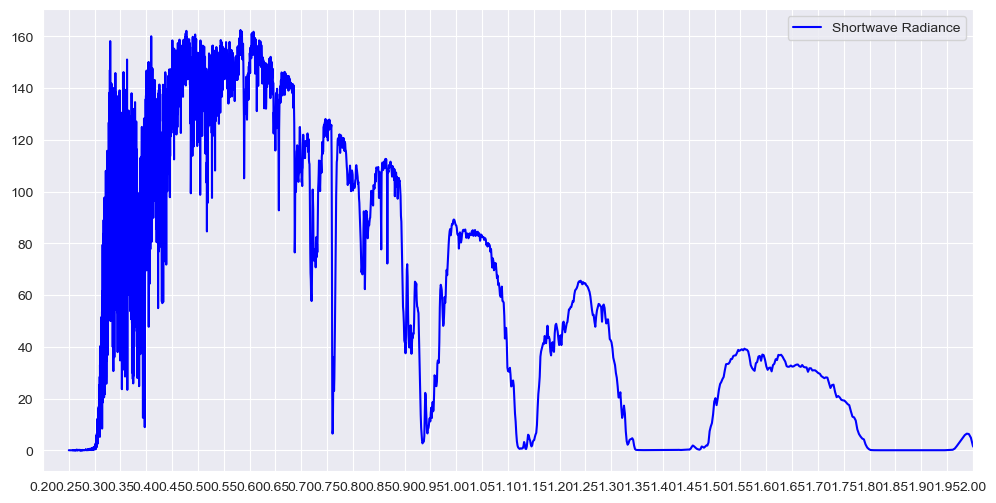

In [39]:
plt.figure(figsize=(12, 6))
x_min = 0.2
x_max = 2.0
tick_interval = 0.05

plt.plot(wv_00, sw_00, label="Shortwave Radiance", color='blue')
plt.xlim(x_min, x_max)


x_ticks = np.arange(x_min, x_max + tick_interval, tick_interval)
plt.xticks(x_ticks)

plt.grid(True)
plt.legend(loc="upper right")
plt.show()

# Actually building V1
## All other work needs to be done above

In [40]:
# a00_data = [Tape7(file) for file in a00_files]
# titles = [file.title for file in a00_data]
# a00 = {title: file for title, file in zip(titles, a00_data)}
# tp7_objs = [Tape7(a00_files[1]), Tape7(a41_files[2])]
# titles = [file.title for file in tp7_objs]
# lnd_ocnclr = {title: file for title, file in zip(titles, tp7_objs)}
# lnd_ocnclr

In [54]:
a41_data = [Tape7(file) for file in a41_files]
titles = [file.title for file in a41_data]
a41 = {title: file for title, file in zip(titles, a41_data)}
tp7_objs = [Tape7(a41_files[1]), Tape7(a41_files[2])]
titles = [file.title for file in tp7_objs]
lnd_ocnclr41 = {title: file for title, file in zip(titles, tp7_objs)}
lnd_ocnclr41

{'Land': <tp7.tp7.Tape7 at 0x33cc50da0>,
 'Clear Ocean': <tp7.tp7.Tape7 at 0x169f43aa0>}

In [55]:
lnd_ocnclr41

{'Land': <tp7.tp7.Tape7 at 0x33cc50da0>,
 'Clear Ocean': <tp7.tp7.Tape7 at 0x169f43aa0>}

In [56]:
ocn41 = lnd_ocnclr["Clear Ocean"]

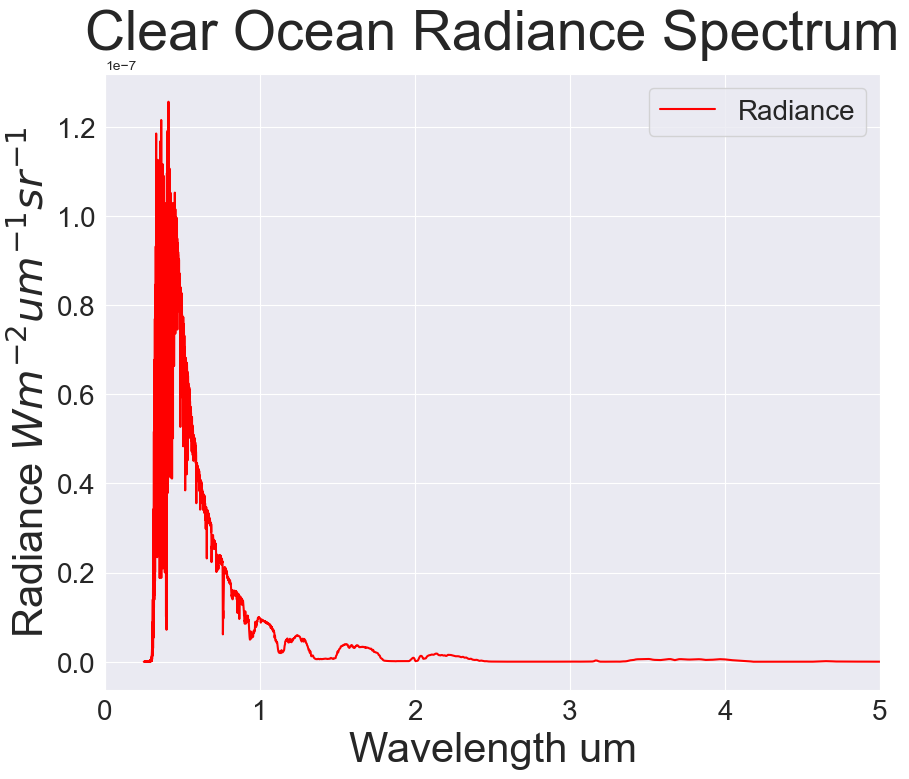

In [57]:
plot_radiance(ocn41.rads, ocn41.title, 0, 1)

In [66]:
land.describer_df['Shortwave Filtered Rads (Integrated)'].max()

258.51237557087126

In [43]:
ocnclr.describer_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Clear Ocean,41.387,0.000,0.0,0,0,3.136356e-08,0.000566,2.119963e-08,3.972862e-11
1,Clear Ocean,41.387,0.000,0.0,0,1,3.712243e-08,0.000562,2.557288e-08,4.904813e-11
2,Clear Ocean,41.387,0.000,0.0,0,2,4.095820e-08,0.000558,2.851947e-08,5.892940e-11
3,Clear Ocean,41.387,0.000,0.0,0,3,4.840163e-08,0.000556,3.424651e-08,7.892688e-11
4,Clear Ocean,41.387,0.000,0.0,0,4,6.282374e-08,0.000554,4.535346e-08,1.188249e-10
...,...,...,...,...,...,...,...,...,...,...
142,Clear Ocean,40.375,89.947,172.5,0,142,2.035709e-07,0.000476,1.520152e-07,5.431468e-11
143,Clear Ocean,40.375,89.947,172.5,0,143,2.200970e-07,0.000476,1.652269e-07,6.449368e-11
144,Clear Ocean,40.375,89.947,172.5,0,144,2.429102e-07,0.000476,1.833262e-07,8.296269e-11
145,Clear Ocean,40.375,89.947,172.5,0,145,2.838958e-07,0.000476,2.156186e-07,1.020558e-10


In [44]:
all_integrated_radiances_land.shape

(4, 630)

In [45]:
np.shape(land.rads)

(630, 3, 4000)

In [46]:
"""
for i runs
    for j bands
        calculate integrated bands for i run and all j bands
"""

for idx, run in enumerate(land.rads):
    for band, rng in viirs_rads_indxs.items():
        y_vals = run[1][rng[0]: rng[1] + 1]
        x_vals = run[0][rng[0]: rng[1] + 1]
        integrated = integrate.simpson(y=y_vals, x=x_vals)
        land.describer_df.loc[idx, band] = integrated

In [47]:
land.describer_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),...,I3,M10,M11,I4,M12,M13,M14,M15,I5,M16
0,Land,0.0,0.000,0.0,0,0,101.967819,98.435473,75.727145,0.016809,...,4.098689,4.098689,0.888305,0.537510,0.270949,0.142514,0.002908,0.003333,0.004053,0.001379
1,Land,0.0,0.000,0.0,1,1,103.227094,69.392565,75.293403,0.003139,...,1.003400,1.003400,0.375608,0.015245,0.007734,0.003539,0.000123,0.000141,0.000334,0.000209
2,Land,0.0,0.000,0.0,1,2,155.619541,60.644086,113.325768,0.002398,...,0.257322,0.257322,0.132324,0.006315,0.003205,0.001267,0.000097,0.000112,0.000304,0.000200
3,Land,0.0,0.000,0.0,1,3,250.712675,93.578042,183.088022,0.021329,...,5.921798,5.921798,1.063389,0.406027,0.223714,0.116470,0.005231,0.003540,0.004254,0.000978
4,Land,0.0,0.000,0.0,1,4,339.815605,86.650577,247.891967,0.029803,...,4.709992,4.709992,0.596189,0.237953,0.131297,0.059864,0.005415,0.005315,0.007217,0.002713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,Land,0.0,79.914,172.5,0,625,72.466530,58.907500,52.043946,0.001230,...,1.397442,1.397442,0.088607,0.023380,0.017252,0.001586,0.000086,0.000493,0.000604,0.000263
626,Land,0.0,79.914,172.5,1,626,83.026982,46.597913,59.707949,0.002290,...,0.347868,0.347868,0.094911,0.007685,0.004315,0.001155,0.000096,0.000164,0.000387,0.000290
627,Land,0.0,79.914,172.5,1,627,106.881209,44.111608,77.204551,0.002583,...,0.271610,0.271610,0.086728,0.007901,0.004311,0.001289,0.000102,0.000164,0.000392,0.000291
628,Land,0.0,79.914,172.5,1,628,157.489675,58.372397,114.987698,0.008196,...,3.889296,3.889296,0.622550,0.137304,0.106363,0.010120,0.001548,0.002602,0.003067,0.001080


In [48]:
land00_corr = land.describer_df.drop(["Scene", "Run #"], axis=1)

In [49]:
land00_corr = land00_corr.corr()

In [50]:
# sns.pairplot(land00_corr)
# plt.show()

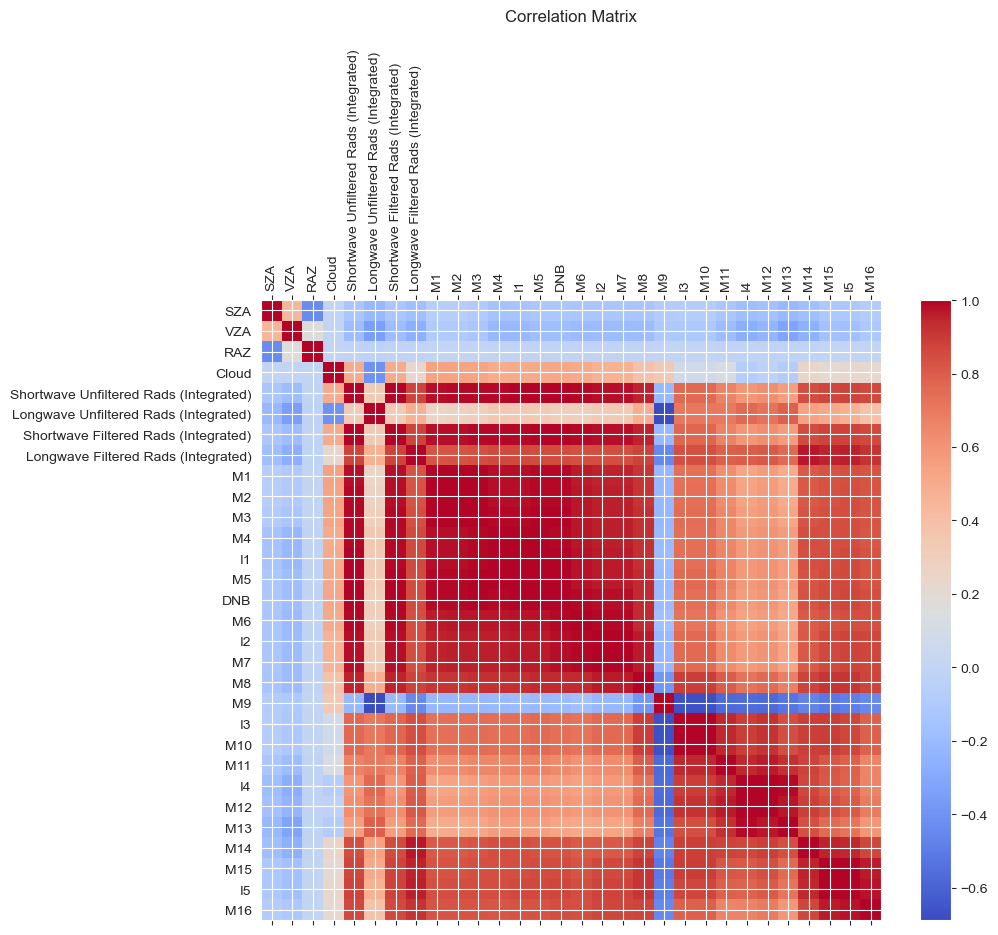

In [51]:
plt.figure(figsize=(10, 8))
plt.matshow(land00_corr, cmap='coolwarm', fignum=1)
plt.colorbar()

plt.xticks(np.arange(land00_corr.shape[1]), land00_corr.columns, rotation=90)
plt.yticks(np.arange(land00_corr.shape[0]), land00_corr.columns)

plt.title("Correlation Matrix", pad=20)
plt.show()

In [52]:
m1_corr = land00_corr["M1"].sort_values(ascending=False)
m1_corr

M1                                        1.000000
M2                                        0.999828
M3                                        0.998003
DNB                                       0.989060
M5                                        0.987699
Shortwave Unfiltered Rads (Integrated)    0.985690
Shortwave Filtered Rads (Integrated)      0.984486
I1                                        0.983653
M4                                        0.982861
M6                                        0.965901
I2                                        0.952898
M7                                        0.952898
M8                                        0.910364
I5                                        0.840111
M15                                       0.828999
Longwave Filtered Rads (Integrated)       0.826614
M16                                       0.822379
M14                                       0.809885
I3                                        0.734270
M10                            

In [53]:
m2_corr = land00_corr["M2"].sort_values(ascending=False)
m2_corr

M2                                        1.000000
M1                                        0.999828
M3                                        0.998869
DNB                                       0.990391
M5                                        0.989856
Shortwave Unfiltered Rads (Integrated)    0.987278
Shortwave Filtered Rads (Integrated)      0.986156
I1                                        0.985902
M4                                        0.984882
M6                                        0.967667
I2                                        0.954618
M7                                        0.954618
M8                                        0.914165
I5                                        0.842794
M15                                       0.832088
Longwave Filtered Rads (Integrated)       0.829593
M16                                       0.823972
M14                                       0.813681
I3                                        0.739239
M10                            